In [1]:
import sys
sys.path.append("..")  # so Python can find the "core" package one level up

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from core.data.preprocess import MovieDataPreprocessor, STUDENT_ID

pipeline = (
    MovieDataPreprocessor()
    .load_raw_data()
    .build_movies_full()
    .build_text_corpus()
    .build_user_item_matrix()
)

# Expose familiar variable names so the analysis cells below
# (sparsity, rating distribution, missing values) keep working unchanged.
ratings = pipeline._ratings
movies = pipeline._movies
links = pipeline._links
movies_full = pipeline.movies_full
text_corpus = pipeline.text_corpus
user_item_matrix = pipeline.user_item_matrix

print(user_item_matrix.shape, text_corpus.shape)

(610, 9724) (3537, 4)


In [2]:
# How many unique users / movies actually appear in the ratings data?
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique() 
n_ratings = len(ratings)

# Sparsity = % of the user-item matrix that has NO rating.
# High sparsity (~98%+) is normal for recommender datasets, but it's
# exactly why plain CF struggles for new users/movies (cold-start).
sparsity = 1- (n_ratings / (n_users * n_movies))

print(f"Unique users: {n_users}")
print(f"Unique movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Matrix Sparsity: {sparsity:.4%}")



Unique users: 610
Unique movies rated: 9724
Total ratings: 100836
Matrix Sparsity: 98.3000%


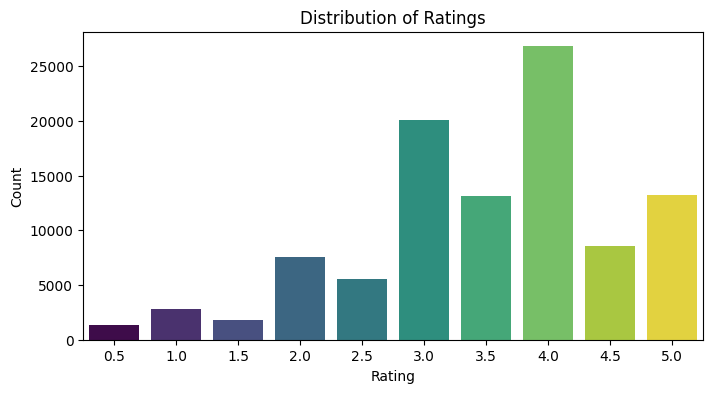

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [3]:
# How are ratings spread out? (0.5 to 5.0 in 0.5 steps)
# This matters because a skewed distribution (e.g. mostly 3-5 stars)
# affects how we interpret RMSE/MAE later in evaluation.

plt.figure(figsize=(8, 4))

# hue=x + legend=False avoids the seaborn deprecation warning
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Check for missing values in movies/links —
# some movies may have no tmdbId, which means no plot overview later.
print("Missing values in movies:\n", movies.isnull().sum())
print("\nMissing values in links:\n", links.isnull().sum())


## Step 1 — Train / Validation / Test Split (60% / 20% / 20%)

Matches the train/validation/test methodology used in COMP813 Assignment 1
(linear regression) and Assignment 2 (CNN classification): every
hyperparameter is tuned on a **validation** set, and the **test** set is
touched only once, at the very end, to report final numbers. The earlier
80/20 train/test split let SVD's `n_factors` get chosen by looking
directly at test performance — a leak this 3-way split removes.


In [4]:
# 3-way per-user split (60% train / 20% validation / 20% test), seeded with
# the student ID — same convention as Assignment 1's np.random.seed(STUDENT_ID).
ds = pipeline.split()  # defaults: val_frac=0.2, test_frac=0.2, seed=STUDENT_ID

print("Train matrix shape:    ", ds.train_matrix.shape)
print("Trainval matrix shape: ", ds.trainval_matrix.shape, "(train+val, for the final refit)")
print("Train rows:", len(ds.train_df), " Val rows:", len(ds.val_df), " Test rows:", len(ds.test_df))

# Sanity checks:
assert ds.train_matrix.shape == pipeline.user_item_matrix.shape, "Grid mismatch!"
assert len(ds.train_df) + len(ds.val_df) + len(ds.test_df) == len(pipeline.ratings), "Rows lost!"

train_pairs = set(zip(ds.train_df.userId, ds.train_df.movieId))
val_pairs = set(zip(ds.val_df.userId, ds.val_df.movieId))
test_pairs = set(zip(ds.test_df.userId, ds.test_df.movieId))
assert not (train_pairs & val_pairs), "train/val overlap!"
assert not (train_pairs & test_pairs), "train/test overlap!"
assert not (val_pairs & test_pairs), "val/test overlap!"

min_train = ds.train_df.groupby("userId").size().min()
print("Min train ratings per user:", min_train, "(must be >= 1)")
print("\nAll sanity checks passed \u2014 splits are disjoint, exhaustive, every user has train data.")


Train matrix shape:     (610, 9724)
Trainval matrix shape:  (610, 9724) (train+val, for the final refit)
Train rows: 60956  Val rows: 19940  Test rows: 19940
Min train ratings per user: 12 (must be >= 1)

All sanity checks passed — splits are disjoint, exhaustive, every user has train data.


## Step 2 — Hyperparameter Search: k × damping (selected on VALIDATION)

Mirrors Assignment 1's Task 1 grid search (learning rate × iterations,
selected by validation MSE): here the two SVD hyperparameters are
`n_factors` (k) and `damping` (how strongly an item's bias is shrunk
toward 0 when it has few ratings — `bias = residual_sum / (count + damping)`).
Both are fit on the 60% TRAIN matrix and scored on the 20% VALIDATION set;
TEST is not touched anywhere in this step.


In [5]:
from core.models.svd import SVDRecommender
from core.evaluation.metrics import evaluate, evaluate_model

# 1. Hyperparameter grid to explore
ks = [5, 10, 15, 20, 30, 50]
damps = [1, 5, 10, 25, 50]

val_rmse_matrix = np.zeros((len(ks), len(damps)))
best_rmse, best_k, best_damp, best_model = float("inf"), None, None, None

# 2. Grid search: fit on TRAIN, select on VALIDATION \u2014 same pattern as
#    Assignment 1's "train on TRAIN, select on VALIDATION" loop.
for i, k in enumerate(ks):
    for j, d in enumerate(damps):
        model = SVDRecommender(n_factors=k, damping=d).fit(ds.train_matrix)
        metrics, n_valid, n_total = evaluate_model(model, ds.val_df)
        val_rmse_matrix[i, j] = metrics["RMSE"]

        if metrics["RMSE"] < best_rmse:   # keep the best FITTED MODEL, not just the (k, damp) pair
            best_rmse, best_k, best_damp, best_model = metrics["RMSE"], k, d, model

print(f"Validation-selected hyperparameters: k={best_k}, damping={best_damp}  (val RMSE={best_rmse:.4f})")


Validation-selected hyperparameters: k=10, damping=5  (val RMSE=0.8789)


### Step 2's Graph — Validation RMSE Heatmap (k vs damping)

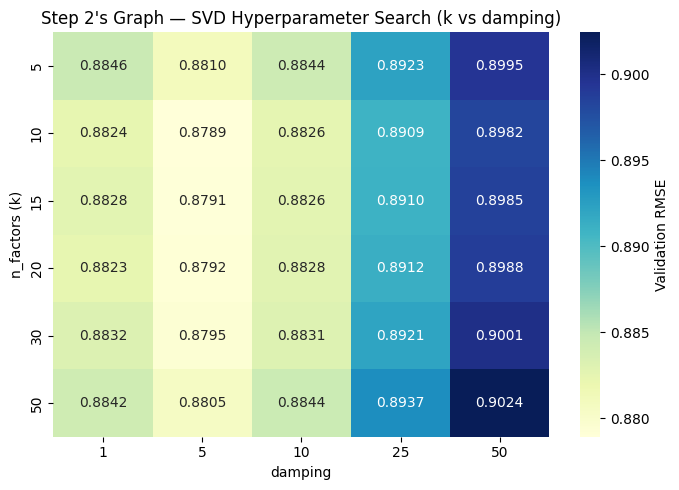

In [6]:
# Heatmap of validation RMSE across the full (k, damping) grid computed in
# Step 2 \u2014 same idea as Assignment 1's val-MSE heatmap, kept in its own
# cell so re-running the (slow) grid search doesn't require re-plotting,
# and vice versa.
plt.figure(figsize=(7, 5))
sns.heatmap(val_rmse_matrix, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=damps, yticklabels=ks,
            cbar_kws={"label": "Validation RMSE"})
plt.title("Step 2's Graph \u2014 SVD Hyperparameter Search (k vs damping)")
plt.xlabel("damping"); plt.ylabel("n_factors (k)")
plt.tight_layout(); plt.show()


## Step 3 — Final Evaluation (Validation + Test, touched ONCE)

Two results, matching Assignment 1's pattern:
1. The **same fitted model** selected in Step 2 (trained on the 60% TRAIN
   split) evaluated on both VALIDATION and TEST — directly comparable to
   Assignment 1's `val_best` / `test_best` table.
2. A **deployment model**, refit on TRAIN+VALIDATION (80%) with the same
   validated hyperparameters, evaluated on TEST — the model that would
   actually ship, since discarding the validation 20% at deployment time
   wastes data for no reason.

TEST is evaluated exactly once in the cell below, for every model in the
final comparison table — never again after this.


In [7]:
# --- 1. Assignment-1-style: the SAME model, evaluated on val AND test ---
val_metrics, _, _ = evaluate_model(best_model, ds.val_df)
test_metrics, _, _ = evaluate_model(best_model, ds.test_df)

a1_style_table = pd.DataFrame([
    {"Set": "Validation", **val_metrics},
    {"Set": "Test (touched once, here)", **test_metrics},
])
print("--- Model selected by validation, evaluated on val + test ---")
print(a1_style_table.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))

# --- 2. Deployment model: refit on TRAIN+VAL (80%), same (k, damping) ---
deploy_model = SVDRecommender(n_factors=best_k, damping=best_damp).fit(ds.trainval_matrix)
deploy_result = evaluate_model(deploy_model, ds.test_df)
deploy_metrics = deploy_result.metrics
print(f"\n--- Deployment model (refit on train+val, 80%) ---")
# coverage() separates real predictions from the user-mean fallback on
# items with zero train ratings - the old n_valid/n_total hid that.
print(f"Test RMSE: {deploy_metrics['RMSE']:.4f}  MAE: {deploy_metrics['MAE']:.4f}")
print(f"Coverage: {deploy_result.coverage()}")

# --- 3. Baseline: user-mean, from the SAME 80% data the deployment model saw ---
user_means = ds.trainval_matrix.mean(axis=1)
baseline_pred = ds.test_df["userId"].map(user_means)
baseline_metrics = evaluate(ds.test_df["rating"], baseline_pred)
print(f"\n--- User-mean baseline (test) ---")
print(f"RMSE: {baseline_metrics['RMSE']:.4f}  MAE: {baseline_metrics['MAE']:.4f}")

# --- 4. External library check: does our custom SVD (with item-bias) beat
#    an off-the-shelf implementation with no item-bias term? Mirrors
#    Assignment 1's "compare against sklearn LinearRegression" step. ---
from sklearn.decomposition import TruncatedSVD

mat = ds.trainval_matrix
means = mat.mean(axis=1)
filled = mat.sub(means, axis=0).fillna(0.0).to_numpy()

sk_svd = TruncatedSVD(n_components=best_k, random_state=STUDENT_ID)
u = sk_svd.fit_transform(filled)
recon = np.clip(u @ sk_svd.components_ + means.to_numpy().reshape(-1, 1), 0.5, 5.0)
recon_df = pd.DataFrame(recon, index=mat.index, columns=mat.columns)

sk_pred = ds.test_df.apply(
    lambda r: recon_df.loc[r["userId"], r["movieId"]] if r["movieId"] in recon_df.columns else np.nan,
    axis=1,
)
sk_valid = sk_pred.notna()
sk_metrics = evaluate(ds.test_df.loc[sk_valid, "rating"], sk_pred[sk_valid])
print(f"\n--- sklearn TruncatedSVD baseline (no item-bias, k={best_k}) ---")
print(f"RMSE: {sk_metrics['RMSE']:.4f}  MAE: {sk_metrics['MAE']:.4f}")

# --- Summary ---
summary = pd.DataFrame([
    {"Model": "User-mean baseline", **baseline_metrics},
    {"Model": f"sklearn TruncatedSVD (k={best_k})", **sk_metrics},
    {"Model": f"Custom SVD, val-selected (k={best_k}, damp={best_damp}) \u2014 train only", **test_metrics},
    {"Model": f"Custom SVD, deployment (k={best_k}, damp={best_damp}) \u2014 train+val", **deploy_metrics},
])
print("\n=== Final test-set comparison (test touched once, in this cell, for every model above) ===")
print(summary.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))


--- Model selected by validation, evaluated on val + test ---
                      Set    MSE   RMSE    MAE
               Validation 0.7725 0.8789 0.6727
Test (touched once, here) 0.7781 0.8821 0.6745

--- Deployment model (refit on train+val, 80%) ---
Test RMSE: 0.8734  MAE: 0.6663
Coverage: 19940/19940 rows predicted; 19146 backed by real evidence, 794 fell back to the user-mean baseline

--- User-mean baseline (test) ---
RMSE: 0.9448  MAE: 0.7353

--- sklearn TruncatedSVD baseline (no item-bias, k=10) ---
RMSE: 0.9153  MAE: 0.7063

=== Final test-set comparison (test touched once, in this cell, for every model above) ===
                                               Model    MSE   RMSE    MAE
                                  User-mean baseline 0.8927 0.9448 0.7353
                         sklearn TruncatedSVD (k=10) 0.8378 0.9153 0.7063
Custom SVD, val-selected (k=10, damp=5) — train only 0.7781 0.8821 0.6745
   Custom SVD, deployment (k=10, damp=5) — train+val 0.7628 0.8734 0.6

### Step 3's Graph — Final Test RMSE Comparison

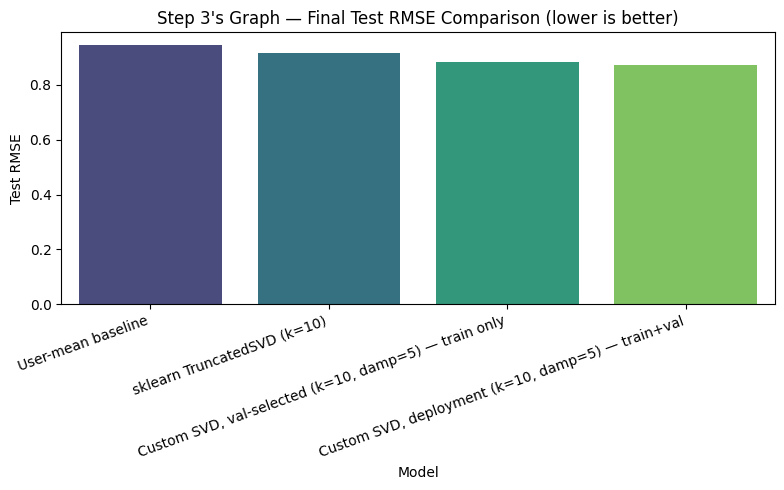

In [8]:
# Bar chart of the `summary` table built in Step 3 \u2014 same "final
# comparison bar chart" pattern as Assignment 1's Task 2 / Task 4.
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="Model", y="RMSE", hue="Model", palette="viridis", legend=False)
plt.title("Step 3's Graph \u2014 Final Test RMSE Comparison (lower is better)")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()


## Step 4 — Ranking Quality: Precision@K / Recall@K / NDCG@K

RMSE measures how close a predicted *number* is to the true rating — it says
nothing about whether the *right movies* end up near the top of a user's
recommendation list, which is what a recommender is actually judged on in
practice. This step re-selects the SVD centering variant on a ranking
metric instead of RMSE, at the (k, damping) already validated in Step 2,
following the same "select on VALIDATION, touch TEST once" discipline as
Steps 2 and 3. The RMSE-best model is not automatically the ranking-best
model: `center="user+item"` wins on RMSE but its item-bias term was shown
earlier to flatten/dominate the top of the ranked list, which hurts NDCG.

In [9]:
from core.evaluation.ranking import (
    build_relevant_items,
    evaluate_ranking,        # single cutoff — used for the centering selection below
    evaluate_ranking_at_ks,  # several cutoffs in ONE pass over the users
)

# 1. Re-select the SVD centering variant for RANKING (not RMSE) on VALIDATION,
#    at the (k, damping) already chosen in Step 2.
relevant_val = build_relevant_items(ds.val_df, threshold=4.0)

ranking_candidates = {}
for center in ["user", "user+item"]:
    m = SVDRecommender(n_factors=best_k, damping=best_damp, center=center).fit(ds.train_matrix)
    recommend_fn = lambda uid, m=m: m.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist()
    ranking_candidates[center] = evaluate_ranking(recommend_fn, relevant_val, k=10)

for center, res in ranking_candidates.items():
    print(f"center={center!r:14s}  NDCG@10={res['NDCG@10']:.4f}  "
          f"Precision@10={res['Precision@10']:.4f}  Recall@10={res['Recall@10']:.4f}  "
          f"(n_users={res['n_users']})")

best_center = max(ranking_candidates, key=lambda c: ranking_candidates[c]["NDCG@10"])
print(f"\nValidation-selected centering for RANKING: center={best_center!r}")

# 2. Refit the ranking-selected variant on TRAIN+VAL (80%) — same "refit once
#    tuning is done" pattern as the deployment model in Step 3.
rank_model = SVDRecommender(n_factors=best_k, damping=best_damp, center=best_center).fit(ds.trainval_matrix)

# 3. Multi-K Precision/Recall/NDCG on TEST, touched once here for ranking.
#    exclude_seen uses rank_model's own _seen_mask, captured from
#    trainval_matrix at fit time, so recommendations correctly skip
#    anything the user rated in TRAIN or VAL.
relevant_test = build_relevant_items(ds.test_df, threshold=4.0)
Ks = [5, 10, 20]
recommend_fn_test = lambda uid: rank_model.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist()

# evaluate_ranking() inside a `for k in Ks` loop rebuilt every user's ranked
# list once per k — 1,806 recommendation builds for 602 users across 3 Ks.
# The list doesn't depend on k, only the cutoff does, so build it once and
# slice it. Identical numbers, ~3x less work.
ranking_by_k = evaluate_ranking_at_ks(recommend_fn_test, relevant_test, Ks)
ranking_results = pd.DataFrame([
    {
        "K": k,
        "Precision": res[f"Precision@{k}"],
        "Recall": res[f"Recall@{k}"],
        "NDCG": res[f"NDCG@{k}"],
        "n_users": res["n_users"],
    }
    for k, res in ranking_by_k.items()
]).set_index("K")

print(f"\n=== Final ranking metrics on TEST (center={best_center!r}, k={best_k}, damping={best_damp}) ===")
print(ranking_results.to_string(formatters={
    c: "{:.4f}".format for c in ["Precision", "Recall", "NDCG"]
}))

center='user'          NDCG@10=0.1060  Precision@10=0.0885  Recall@10=0.0725  (n_users=598)
center='user+item'     NDCG@10=0.0398  Precision@10=0.0360  Recall@10=0.0240  (n_users=598)

Validation-selected centering for RANKING: center='user'

=== Final ranking metrics on TEST (center='user', k=10, damping=5) ===
   Precision Recall   NDCG  n_users
K                                  
5     0.1415 0.0549 0.1596      602
10    0.1164 0.0911 0.1502      602
20    0.0870 0.1328 0.1456      602


### Step 4's Graph — Centering Selection & Ranking Metrics vs K

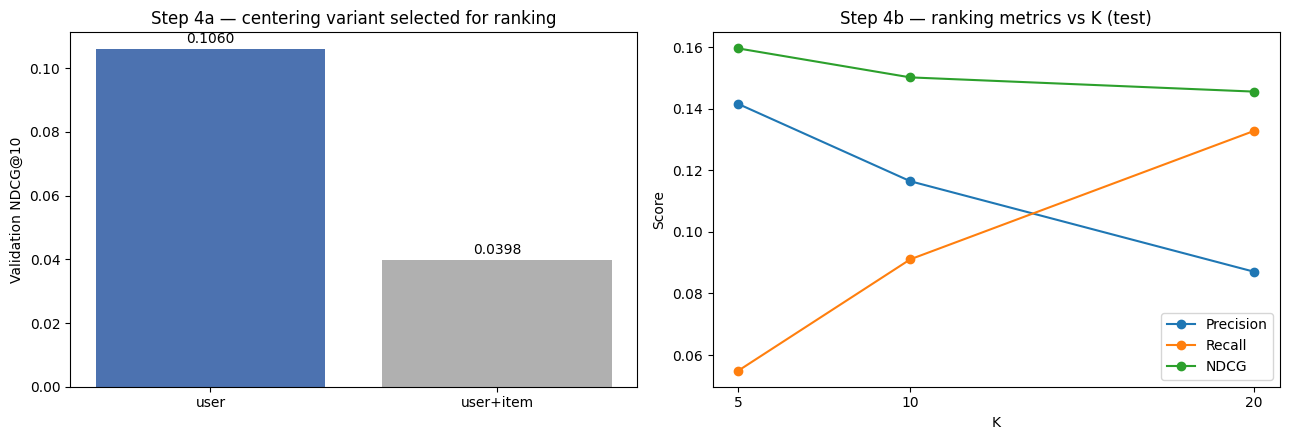

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: validation NDCG@10 by centering variant — shows why best_center was picked
centers = list(ranking_candidates.keys())
ndcgs = [ranking_candidates[c]["NDCG@10"] for c in centers]
colors = ["#4C72B0" if c == best_center else "#B0B0B0" for c in centers]
axes[0].bar(centers, ndcgs, color=colors)
axes[0].set_ylabel("Validation NDCG@10")
axes[0].set_title("Step 4a — centering variant selected for ranking")
for i, v in enumerate(ndcgs):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center")

# Right: Precision/Recall/NDCG vs K on test, for the ranking-selected model
for metric in ["Precision", "Recall", "NDCG"]:
    axes[1].plot(ranking_results.index, ranking_results[metric], marker="o", label=metric)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 4b — ranking metrics vs K (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5 — Content-Based Model (TF-IDF on plot overviews)

Steps 2-4 are pure Collaborative Filtering: every prediction comes from *other
users' ratings*, so an item nobody has rated yet cannot be ranked at all. This
step adds the NLP half of the project — a TF-IDF + cosine-similarity model over
TMDB plot overviews, which needs no ratings for the item it is scoring.

Two things differ from Steps 2-4 and both are deliberate:

1. **Ranking metrics only, no RMSE.** This model outputs cosine similarity
   (roughly 0-1), not a star rating, so RMSE against a 0.5-5.0 rating column is
   a category error — it produced a meaningless "RMSE 3.71" before
   `evaluate_model()` was taught to refuse it (`produces_ratings = False`).
2. **Coverage is reported first.** The model can only speak for movies that have
   plot text, and that is a minority of the catalogue. Quoting its ranking
   scores without that caveat would overstate what it contributes.

Same discipline as before: `use_genres` is selected on VALIDATION, the winner is
refit on TRAIN+VAL, and TEST is touched once.

In [11]:
from core.models.content import ContentBasedRecommender

# --- 1. Coverage: what fraction of the catalogue can this model even score? ---
# Reported BEFORE the metrics on purpose. A content model that looks mediocre
# overall may simply have no text for most items, which is a data-collection
# problem, not a modelling one — the report needs to separate the two.
text_ids = set(text_corpus["movieId"]) & set(ds.train_matrix.columns)
n_items = ds.train_matrix.shape[1]
print(f"Movies with plot text: {len(text_ids)}/{n_items} "
      f"({100 * len(text_ids) / n_items:.1f}% of the rated catalogue)")

train_counts = ds.train_matrix.notna().sum(axis=0)
cold_ids = set(train_counts[train_counts == 0].index)
print(f"Items with 0 train ratings: {len(cold_ids)}; of those, {len(cold_ids & text_ids)} have text "
      f"({100 * len(cold_ids & text_ids) / len(cold_ids):.1f}% of the cold-start cases "
      f"this model can currently reach)")

# --- 2. Select use_genres on VALIDATION ranking (its only hyperparameter) ---
# Genre tokens are appended to the plot text when True. Same select-on-validation
# pattern as Step 2's (k, damping) grid and Step 4's centering choice.
content_candidates = {}
for use_genres in [False, True]:
    cm = ContentBasedRecommender(use_genres=use_genres).fit(ds.train_matrix, text_corpus)
    # recommend_top_n() now excludes the user's train-rated movies by default,
    # using the mask captured in fit(). It previously required the caller to
    # pass seen_movie_ids and silently excluded NOTHING when they didn't —
    # which filled the top-10 with movies the user had already rated.
    fn = lambda uid, cm=cm: cm.recommend_top_n(uid, n=10).index.tolist()
    res = evaluate_ranking(fn, relevant_val, k=10)
    content_candidates[use_genres] = res
    print(f"use_genres={str(use_genres):<5}  NDCG@10={res['NDCG@10']:.4f}  "
          f"Precision@10={res['Precision@10']:.4f}  Recall@10={res['Recall@10']:.4f}  "
          f"(n_users={res['n_users']}, no recommendations for {res['n_no_recs']})")

best_use_genres = max(content_candidates, key=lambda g: content_candidates[g]["NDCG@10"])
print(f"\nValidation-selected: use_genres={best_use_genres}")

# --- 3. Refit on TRAIN+VAL (80%), evaluate on TEST once, at Step 4's Ks ---
content_model = ContentBasedRecommender(use_genres=best_use_genres).fit(
    ds.trainval_matrix, text_corpus
)
recommend_fn_content = lambda uid: content_model.recommend_top_n(uid, n=max(Ks)).index.tolist()

content_by_k = evaluate_ranking_at_ks(recommend_fn_content, relevant_test, Ks)
content_results = pd.DataFrame([
    {
        "K": k,
        "Precision": res[f"Precision@{k}"],
        "Recall": res[f"Recall@{k}"],
        "NDCG": res[f"NDCG@{k}"],
        "n_users": res["n_users"],
    }
    for k, res in content_by_k.items()
]).set_index("K")

print(f"\n=== Content-based model on TEST (use_genres={best_use_genres}) ===")
print(content_results.to_string(formatters={
    c: "{:.4f}".format for c in ["Precision", "Recall", "NDCG"]
}))

# --- 4. Sanity check that the seen-exclusion fix is actually in effect ---
# Guards the exact bug described above: if this ever prints a non-zero number,
# the model is "recommending" movies the user already rated and every ranking
# score in this step is inflated and meaningless.
leaked = 0
for uid in list(ds.trainval_matrix.index)[:50]:
    already_rated = set(ds.train_df.loc[ds.train_df.userId == uid, "movieId"]) | \
                    set(ds.val_df.loc[ds.val_df.userId == uid, "movieId"])
    leaked += len(set(recommend_fn_content(uid)) & already_rated)
print(f"\nSanity check — already-rated movies in the first 50 users' recommendations: {leaked} (must be 0)")

# --- 5. Side by side with Step 4's SVD, which is the point of the comparison ---
comparison = ranking_results[["Precision", "Recall", "NDCG"]].join(
    content_results[["Precision", "Recall", "NDCG"]], lsuffix=" (SVD)", rsuffix=" (Content)"
)
print("\n=== SVD vs Content-based on TEST ===")
print(comparison.to_string(formatters={c: "{:.4f}".format for c in comparison.columns}))

Movies with plot text: 3536/9724 (36.4% of the rated catalogue)
Items with 0 train ratings: 1641; of those, 297 have text (18.1% of the cold-start cases this model can currently reach)
use_genres=False  NDCG@10=0.0401  Precision@10=0.0265  Recall@10=0.0246  (n_users=597, no recommendations for 1)
use_genres=True   NDCG@10=0.0382  Precision@10=0.0255  Recall@10=0.0241  (n_users=597, no recommendations for 1)

Validation-selected: use_genres=False

=== Content-based model on TEST (use_genres=False) ===
   Precision Recall   NDCG  n_users
K                                  
5     0.0373 0.0256 0.0533      601
10    0.0255 0.0313 0.0469      601
20    0.0167 0.0383 0.0448      601

Sanity check — already-rated movies in the first 50 users' recommendations: 0 (must be 0)

=== SVD vs Content-based on TEST ===
   Precision (SVD) Recall (SVD) NDCG (SVD) Precision (Content) Recall (Content) NDCG (Content)
K                                                                                         

### Step 5's Graph — Content vs SVD, and why a hybrid is the next step

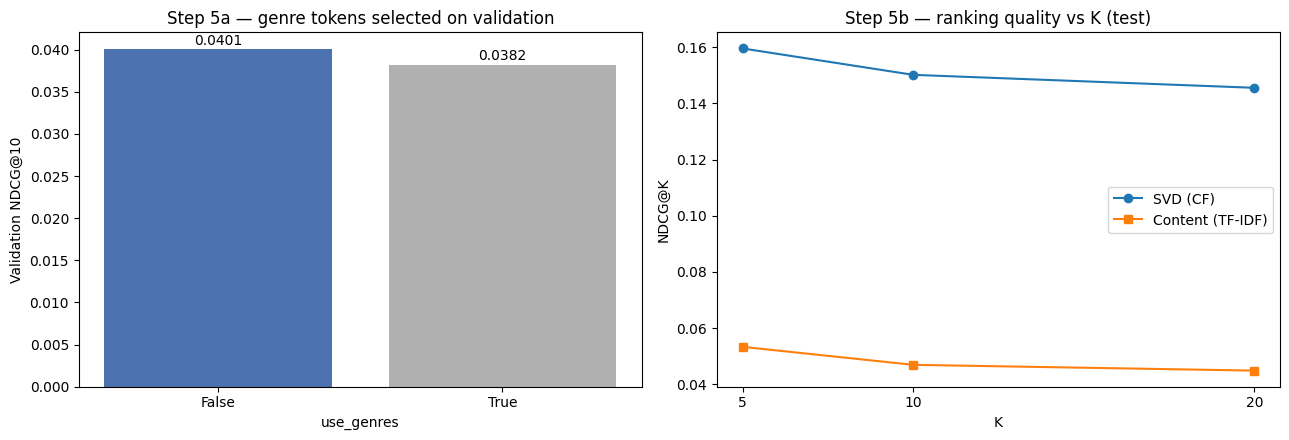

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: validation NDCG@10 by use_genres — shows why best_use_genres was picked.
opts = [str(g) for g in content_candidates]
vals = [content_candidates[g]["NDCG@10"] for g in content_candidates]
cols = ["#4C72B0" if g == best_use_genres else "#B0B0B0" for g in content_candidates]
axes[0].bar(opts, vals, color=cols)
axes[0].set_xlabel("use_genres")
axes[0].set_ylabel("Validation NDCG@10")
axes[0].set_title("Step 5a — genre tokens selected on validation")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha="center")

# Right: NDCG@K on test, both models on one axis. The gap is the argument for
# the hybrid: content is much weaker alone, but it is the only one of the two
# that can score an item with no ratings at all.
axes[1].plot(ranking_results.index, ranking_results["NDCG"], marker="o", label="SVD (CF)")
axes[1].plot(content_results.index, content_results["NDCG"], marker="s", label="Content (TF-IDF)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("NDCG@K")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 5b — ranking quality vs K (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 6 — Responsible AI: Popularity Bias & Cold-Start Fairness

Ranking quality (Step 4/5) asks "are the recommendations good". This step
asks a different question: "good for whom, and at whose expense". Two
checks, both cheap to compute from data already built:

1. **Popularity bias** — does a "personalized" model actually personalize,
   or does it mostly reshuffle the same best-sellers for everyone? Measured
   against a naive Most-Popular baseline (no personalization at all) as the
   reference point: catalogue coverage (how much of the 9,724-movie catalogue
   ever gets recommended to anyone) and the mean popularity of recommended
   items vs the catalogue average.
2. **Cold-start fairness** — demonstrated in Step 6b below: Step 3
   showed SVD's RMSE on items with zero train ratings collapses exactly to
   the user-mean baseline (no real signal at all), and Step 5 showed the
   content model only has plot text for 18% of those same items. Together
   this means a user whose taste skews toward niche, rarely-rated movies is
   systematically underserved by EITHER model alone — not a ranking-quality
   gap, a coverage gap. This is the strongest argument for the hybrid: it
   isn't just "better NDCG", it's "serves the users the other two don't".

In [13]:
# Item popularity: how many TRAIN+VAL ratings each item received — the raw
# signal a collaborative model implicitly leans on (more raters -> more
# reliable signal -> easier to get right, which is exactly the bias risk).
popularity = ds.trainval_matrix.notna().sum(axis=0)  # Series indexed by movieId
catalog_avg_popularity = popularity.mean()
# kind="mergesort" is STABLE, matching SVDRecommender.recommend_top_n(). The
# default quicksort is not, and popularity counts are almost all ties:
# 9,682 of 9,724 items share their count with another item, and 79 of the
# top 120 sit in a tied group, so an unstable sort silently reshuffles the
# baseline's top-N between runs and its NDCG drifts in the 4th decimal.
# Stable sorting makes ties resolve to ascending movieId, deterministically.
popularity_ranked = popularity.sort_values(ascending=False, kind="mergesort")

# Naive "most popular" recommender: zero personalization, same best-sellers
# for everyone minus what they've already rated. The reference point — if
# SVD/content aren't meaningfully less concentrated than THIS, personalization
# isn't buying much diversity, whatever the ranking metrics say.
# islice stops as soon as n items are found. The list-comprehension version
# filtered all 9,724 items for every user before slicing 10 off the front —
# ~5.9M membership tests across 610 users to produce 6,100 recommendations.
from itertools import islice

seen_by_user = {
    uid: set(ds.trainval_matrix.columns[ds.trainval_matrix.loc[uid].notna()])
    for uid in ds.trainval_matrix.index
}

def recommend_popular(user_id, n=10):
    if user_id not in ds.trainval_matrix.index:
        return []
    seen = seen_by_user[user_id]
    return list(islice((m for m in popularity_ranked.index if m not in seen), n))

recommenders = {
    "SVD (personalized)": lambda uid: rank_model.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist(),
    "Content (personalized)": lambda uid: content_model.recommend_top_n(uid, n=10).index.tolist(),
    "Most-Popular (naive)": recommend_popular,
}

# What each recommender could rank even in principle. SVD and Most-Popular see
# the whole rated catalogue; the content model only sees movies with plot text.
n_text_items = len(set(text_corpus["movieId"]) & set(ds.trainval_matrix.columns))
reachable_pool = {
    "SVD (personalized)": len(popularity),
    "Content (personalized)": n_text_items,
    "Most-Popular (naive)": len(popularity),
}

all_users = ds.trainval_matrix.index
bias_rows = []
for name, fn in recommenders.items():
    recommended_items = set()
    pop_values = []
    for uid in all_users:
        for m in fn(uid):
            recommended_items.add(m)
            pop_values.append(popularity.get(m, 0))
    bias_rows.append({
        "Recommender": name,
        "Catalog coverage": len(recommended_items) / len(popularity),
        # Coverage against the full catalogue is unfair to the content model:
        # it can only ever rank the ~36% of movies that HAVE plot text, so its
        # catalogue-wide number understates how much of its own reachable space
        # it uses. Dividing by each model's reachable pool makes the diversity
        # comparison apples-to-apples.
        "Coverage of reachable pool": len(recommended_items) / reachable_pool[name],
        "Mean popularity of recs": float(np.mean(pop_values)) if pop_values else np.nan,
    })

bias_df = pd.DataFrame(bias_rows).set_index("Recommender")
print(f"Catalogue-average item popularity: {catalog_avg_popularity:.1f} ratings/item")
print(bias_df.to_string(formatters={
    "Catalog coverage": "{:.1%}".format,
    "Coverage of reachable pool": "{:.1%}".format,
    "Mean popularity of recs": "{:.1f}".format,
}))

Catalogue-average item popularity: 8.3 ratings/item
                       Catalog coverage Coverage of reachable pool Mean popularity of recs
Recommender                                                                               
SVD (personalized)                 4.0%                       4.0%                   138.9
Content (personalized)            17.8%                      48.9%                    22.3
Most-Popular (naive)               0.6%                       0.6%                   196.9


### Step 6b — Does personalization actually beat "recommend the best-sellers"?

The Most-Popular recommender above is not just a bias reference point — it is
the standard sanity baseline in recommender-systems evaluation, and it has to
be scored on the SAME ranking metrics as the real models. A personalized model
that cannot beat a non-personalized one is not yet earning its complexity, and
that is a result worth reporting honestly rather than leaving unmeasured.

This cell also supplies the evidence for the cold-start claim made above, which
until now was asserted rather than demonstrated: on test ratings for items with
zero train+val ratings, SVD's prediction is not merely *close to* the user-mean
baseline, it is **identical to it**, because the factor model reconstructs
nothing for a column it never saw.

In [14]:
# --- 1. Score Most-Popular on the same ranking metrics as SVD and Content ---
baseline_rankers = {
    "SVD (personalized)": lambda uid: rank_model.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist(),
    "Content (personalized)": lambda uid: content_model.recommend_top_n(uid, n=max(Ks)).index.tolist(),
    "Most-Popular (naive)": lambda uid: recommend_popular(uid, n=max(Ks)),
}

bias_ranking = {
    name: evaluate_ranking_at_ks(fn, relevant_test, Ks)
    for name, fn in baseline_rankers.items()
}

ndcg_table = pd.DataFrame(
    {name: {k: res[k][f"NDCG@{k}"] for k in Ks} for name, res in bias_ranking.items()}
)
ndcg_table.index.name = "K"
precision_table = pd.DataFrame(
    {name: {k: res[k][f"Precision@{k}"] for k in Ks} for name, res in bias_ranking.items()}
)
precision_table.index.name = "K"

print("=== NDCG@K on TEST — personalized models vs the naive baseline ===")
print(ndcg_table.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n=== Precision@K on TEST ===")
print(precision_table.to_string(float_format=lambda v: f"{v:.4f}"))

svd_wins = int((ndcg_table["SVD (personalized)"] > ndcg_table["Most-Popular (naive)"]).sum())
print(f"\nSVD beats Most-Popular on NDCG at {svd_wins} of {len(Ks)} cutoffs.")
print("Note: SVD DOES clearly win on rating error (Step 3: test RMSE "
      f"{deploy_metrics['RMSE']:.4f} vs {baseline_metrics['RMSE']:.4f} for the user-mean baseline).")
print("Winning at rating prediction while not winning at ranking is the whole")
print("reason Step 4 separates the two metric families — and the motivation for")
print("the hybrid: a model that cannot out-rank best-sellers needs a second signal.")

# --- 2. Evidence for the cold-start claim: SVD == user-mean on unseen items ---
cold_items = popularity[popularity == 0].index
cold_rows = ds.test_df[ds.test_df["movieId"].isin(cold_items)]
trainval_user_means = ds.trainval_matrix.mean(axis=1)

cold_svd = cold_rows.apply(
    lambda r: deploy_model.predict(r["userId"], r["movieId"]), axis=1
).astype(float)
cold_mean = cold_rows["userId"].map(trainval_user_means).astype(float)

print(f"\n=== Cold-start evidence ===")
print(f"Items with 0 train+val ratings: {len(cold_items)}; test ratings on them: {len(cold_rows)}")
print(f"Max |SVD prediction - user mean| on those rows: {np.abs(cold_svd - cold_mean).max():.2e}")
print(f"SVD RMSE on cold rows:       {evaluate(cold_rows['rating'], cold_svd)['RMSE']:.4f}")
print(f"User-mean RMSE on cold rows: {evaluate(cold_rows['rating'], cold_mean)['RMSE']:.4f}")
print("Identical, as expected: for a column with no ratings the reconstruction")
print("contributes nothing, so the 'prediction' is the user's own average.")

=== NDCG@K on TEST — personalized models vs the naive baseline ===
    SVD (personalized)  Content (personalized)  Most-Popular (naive)
K                                                                   
5               0.1596                  0.0533                0.1641
10              0.1502                  0.0469                0.1549
20              0.1456                  0.0448                0.1562

=== Precision@K on TEST ===
    SVD (personalized)  Content (personalized)  Most-Popular (naive)
K                                                                   
5               0.1415                  0.0373                0.1429
10              0.1164                  0.0255                0.1153
20              0.0870                  0.0167                0.0885

SVD beats Most-Popular on NDCG at 0 of 3 cutoffs.
Note: SVD DOES clearly win on rating error (Step 3: test RMSE 0.8734 vs 0.9448 for the user-mean baseline).
Winning at rating prediction while not winning at ranki

### Step 6's Graph — Coverage and Popularity Bias vs the Naive Baseline

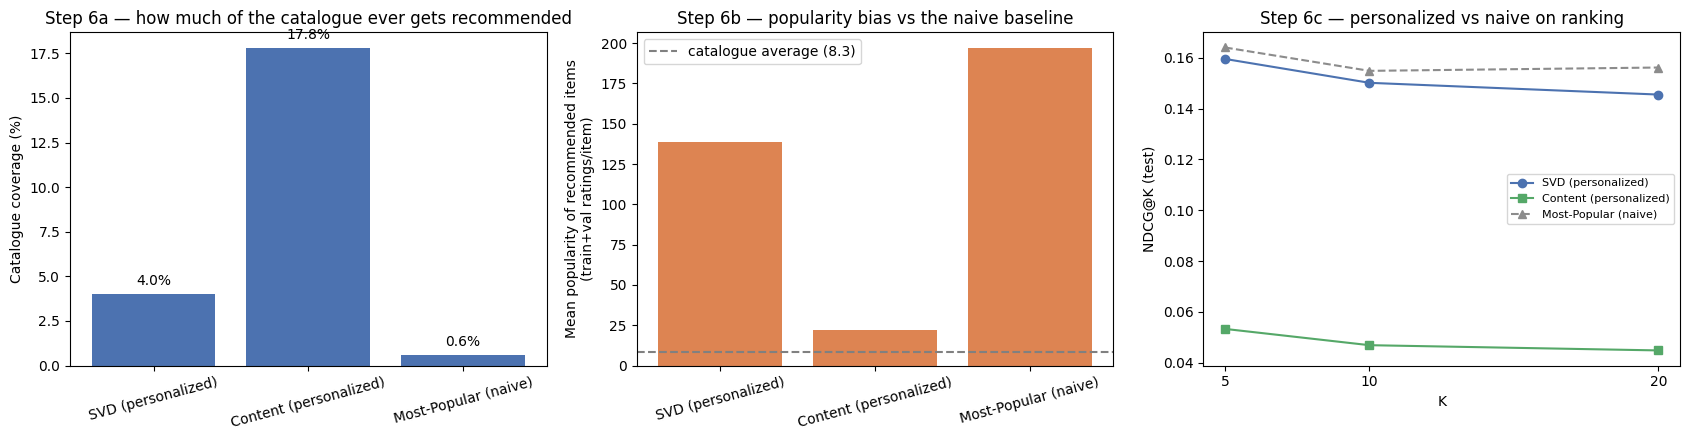

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].bar(bias_df.index, bias_df["Catalog coverage"] * 100, color="#4C72B0")
axes[0].set_ylabel("Catalogue coverage (%)")
axes[0].set_title("Step 6a — how much of the catalogue ever gets recommended")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(bias_df["Catalog coverage"] * 100):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

axes[1].bar(bias_df.index, bias_df["Mean popularity of recs"], color="#DD8452")
axes[1].axhline(catalog_avg_popularity, color="gray", linestyle="--",
                 label=f"catalogue average ({catalog_avg_popularity:.1f})")
axes[1].set_ylabel("Mean popularity of recommended items\n(train+val ratings/item)")
axes[1].set_title("Step 6b — popularity bias vs the naive baseline")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

# Third panel is the one that matters most for the report: if the grey naive
# baseline sits at or above the personalized models, personalization is not
# paying for itself yet on ranking.
styles = {"SVD (personalized)": ("#4C72B0", "o", "-"),
          "Content (personalized)": ("#55A868", "s", "-"),
          "Most-Popular (naive)": ("#8C8C8C", "^", "--")}
for name in ndcg_table.columns:
    color, marker, ls = styles[name]
    axes[2].plot(ndcg_table.index, ndcg_table[name], marker=marker, linestyle=ls,
                 color=color, label=name)
axes[2].set_xlabel("K"); axes[2].set_ylabel("NDCG@K (test)")
axes[2].set_xticks(Ks)
axes[2].set_title("Step 6c — personalized vs naive on ranking")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()